# ClimateNet AR Analysis: Western US

In [1]:
import numpy as np
import xarray as xr
import xesmf as xe
import nc_time_axis
import cftime 
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.util import add_cyclic_point
import cartopy.mpl.ticker as cticker
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib as mpl
import matplotlib.patches as mpatches

In [2]:
# Import dask
import dask

# Use dask jobqueue
from dask_jobqueue import PBSCluster

# Import a client
from dask.distributed import Client

# Setup your PBSCluster
nmem1 = '5GiB' # PBSCluster specification
nmem2 = '5GB' # pbs specification
cluster = PBSCluster(
    cores=1, # The number of cores you want
    memory=nmem1, # Amount of memory
    processes=1, # How many processes
    queue='casper', # The type of queue to utilize (/glade/u/apps/dav/opt/usr/bin/execcasper)
    local_directory='/glade/derecho/scratch/kdagon/dask-local', # Use your local directory
    resource_spec='select=1:ncpus=1:mem='+nmem2, # Specify resources
    account='P06010014', # Input your project ID here
    walltime='03:00:00', # Amount of wall time
    interface='ext', # Interface to use
)

# Scale up -- how to determine this number?
cluster.scale(10)

# Change your url to the dask dashboard so you can see it
dask.config.set({'distributed.dashboard.link':'https://jupyterhub.hpc.ucar.edu/stable/user/{USER}/proxy/{port}/status'})
#dask.config.set({'distributed.dashboard.link':'https://jupyterhub.hpc.ucar.edu/stable/user/{USER}/GPU/proxy/{port}/status'}) # need to include name of server if named!
# the above is for jupyterhub only, otherwise use /proxy/{port}/status (also need to launch ssh tunneling from the appropriate environment)
#dask.config.set({'distributed.dashboard.link': "/proxy/{port}/status"})
# really I should set these options in some sort of config file...

# Setup your client
client = Client(cluster)

/glade/work/kdagon/miniconda/envs/PEx/lib/python3.9/site-packages/distributed/node.py:183: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 37927 instead
  warnings.warn(


In [3]:
client

Connection method: Cluster object,Cluster type: dask_jobqueue.PBSCluster
Dashboard: https://jupyterhub.hpc.ucar.edu/stable/user/kdagon/proxy/37927/status,
Dashboard: https://jupyterhub.hpc.ucar.edu/stable/user/kdagon/proxy/37927/status,Workers: 0
Total threads: 0,Total memory: 0 B
Comm: tcp://128.117.208.98:35645,Workers: 0
Dashboard: https://jupyterhub.hpc.ucar.edu/stable/user/kdagon/proxy/37927/status,Total threads: 0
Started: 1 minute ago,Total memory: 0 B


## Analysis notes
- replace `.where` with `.clip` if possible for speed

## Set ClimateNet filepath

In [4]:
cesm_cnet_filepath = "/glade/campaign/cgd/ccr/kdagon/cgnet/" # retrained NCAR model, after data processing workflow was finalized

## Set regional bounds

In [5]:
# Western US domain from Payne & Magnusdottir (2014,2015) papers (estimated, modified to include land at all lons)
#lat_bounds = slice(25,61)
#lon_bounds = slice(189, 250)

# Restricted western US (mostly land) domain from Collow et al. 2020
#lat_bounds = slice(32,50)
#lon_bounds = slice(235,246)

# Western US/Eastern Pacific domain from ARTMIP
lat_bounds = slice(25,65)
lon_bounds = slice(180,255)

### Preprocessing function to subset regionally

In [6]:
def preprocess_region(ds):
    # return regional domain
    return ds['masks'].sel(lat=lat_bounds,lon=lon_bounds)

## CESM historical simulation

In [7]:
hist_yrs = [str(i) for i in range(2000,2006)]
#hist_folders = ["B20TRC5CN/"+y+"/masks/" for y in hist_yrs]
hist_folders = ["B20TRC5CN/"+y+"/masks_unwgt/" for y in hist_yrs] # unweighted means/std

In [8]:
cnet_file = 'class_masks.nc' # can't use wildcard for this to work?
hist_paths = [cesm_cnet_filepath+hist_folders[i]+cnet_file for i,f in enumerate(hist_folders)]
hist_paths

['/glade/campaign/cgd/ccr/kdagon/cgnet/B20TRC5CN/2000/masks_unwgt/class_masks.nc',
 '/glade/campaign/cgd/ccr/kdagon/cgnet/B20TRC5CN/2001/masks_unwgt/class_masks.nc',
 '/glade/campaign/cgd/ccr/kdagon/cgnet/B20TRC5CN/2002/masks_unwgt/class_masks.nc',
 '/glade/campaign/cgd/ccr/kdagon/cgnet/B20TRC5CN/2003/masks_unwgt/class_masks.nc',
 '/glade/campaign/cgd/ccr/kdagon/cgnet/B20TRC5CN/2004/masks_unwgt/class_masks.nc',
 '/glade/campaign/cgd/ccr/kdagon/cgnet/B20TRC5CN/2005/masks_unwgt/class_masks.nc']

### Read in masks with preprocessing

In [9]:
%%time
cnet_hist_shift = xr.open_mfdataset(hist_paths, concat_dim='time',combine='nested', chunks={'time':500}, parallel=True, preprocess=preprocess_region)

CPU times: user 6.45 s, sys: 421 ms, total: 6.87 s
Wall time: 1min 19s


In [10]:
cnet_hist_shift

<xarray.DataArray 'masks' (time: 17520, lat: 170, lon: 241)>
dask.array<concatenate, shape=(17520, 170, 241), dtype=int64, chunksize=(500, 170, 241), chunktype=numpy.ndarray>
Coordinates:
  * lon      (lon) float64 180.0 180.3 180.6 180.9 ... 254.1 254.4 254.7 255.0
  * lat      (lat) float64 25.23 25.46 25.7 25.93 ... 64.19 64.42 64.65 64.89
  * time     (time) object 2000-01-01 03:00:00 ... 2006-01-01 00:00:00
Attributes: (12/21)
    CDI:                        Climate Data Interface version 2.0.2 (https:/...
    Conventions:                CF-1.0
    source:                     CAM
    history:                    Fri Feb 17 16:11:24 2023: cdo splitsel,1 2000...
    remap_script:               ncremap
    remap_command:              '/glade/u/apps/dav/opt/nco/4.7.9/gnu/8.3.0/bi...
    ...                         ...
    Version:                    $Name$
    revision_Id:                $Id$
    initial_file:               /projects/ccsm/inputdata/atm/cam/inic/homme/c...
    topography_file:            /projects/ccsm/inputdata/atm/cam/topo/USGS-gt...
    history_of_appended_files:  Fri Feb 17 15:31:33 2023: Appended file 2000_...
    CDO:                        Climate Data Operators version 2.0.1 (https:/...

### Shift time indices of 2000-2005 back 3hrs to avoid duplicative index

In [11]:
timeshift = cnet_hist_shift.sel(time=slice("2000-01-01 03:00:00","2006-01-01 00:00:00")).time.indexes['time'].shift(-3,"H")

In [12]:
timeshift

CFTimeIndex([2000-01-01 00:00:00, 2000-01-01 03:00:00, 2000-01-01 06:00:00,
             2000-01-01 09:00:00, 2000-01-01 12:00:00, 2000-01-01 15:00:00,
             2000-01-01 18:00:00, 2000-01-01 21:00:00, 2000-01-02 00:00:00,
             2000-01-02 03:00:00,
             ...
             2005-12-30 18:00:00, 2005-12-30 21:00:00, 2005-12-31 00:00:00,
             2005-12-31 03:00:00, 2005-12-31 06:00:00, 2005-12-31 09:00:00,
             2005-12-31 12:00:00, 2005-12-31 15:00:00, 2005-12-31 18:00:00,
             2005-12-31 21:00:00],
            dtype='object', length=17520, calendar='noleap', freq='3H')

In [13]:
cnet_hist = cnet_hist_shift.sel(time=slice("2000-01-01 03:00:00","2006-01-01 00:00:00")).assign_coords(time=timeshift)
cnet_hist

<xarray.DataArray 'masks' (time: 17520, lat: 170, lon: 241)>
dask.array<concatenate, shape=(17520, 170, 241), dtype=int64, chunksize=(500, 170, 241), chunktype=numpy.ndarray>
Coordinates:
  * lon      (lon) float64 180.0 180.3 180.6 180.9 ... 254.1 254.4 254.7 255.0
  * lat      (lat) float64 25.23 25.46 25.7 25.93 ... 64.19 64.42 64.65 64.89
  * time     (time) object 2000-01-01 00:00:00 ... 2005-12-31 21:00:00
Attributes: (12/21)
    CDI:                        Climate Data Interface version 2.0.2 (https:/...
    Conventions:                CF-1.0
    source:                     CAM
    history:                    Fri Feb 17 16:11:24 2023: cdo splitsel,1 2000...
    remap_script:               ncremap
    remap_command:              '/glade/u/apps/dav/opt/nco/4.7.9/gnu/8.3.0/bi...
    ...                         ...
    Version:                    $Name$
    revision_Id:                $Id$
    initial_file:               /projects/ccsm/inputdata/atm/cam/inic/homme/c...
    topography_file:            /projects/ccsm/inputdata/atm/cam/topo/USGS-gt...
    history_of_appended_files:  Fri Feb 17 15:31:33 2023: Appended file 2000_...
    CDO:                        Climate Data Operators version 2.0.1 (https:/...

## CESM RCP2.6 simulation

In [14]:
rcp26_yrs = [str(i) for i in range(2006,2016)]
#rcp26_folders = ["BRCP26C5CN/"+y+"/masks/" for y in rcp26_yrs]
#rcp26_folders = ["BRCP26C5CN/"+y+"/masks_v2/" for y in rcp26_yrs] # updated data processing (3hrly PSL)
rcp26_folders = ["BRCP26C5CN/"+y+"/masks_unwgt/" for y in rcp26_yrs] # unweighted means/std

In [15]:
cnet_file = 'class_masks.nc' # can't use wildcard for this to work?
rcp26_paths = [cesm_cnet_filepath+rcp26_folders[i]+cnet_file for i,f in enumerate(rcp26_folders)]
rcp26_paths

['/glade/campaign/cgd/ccr/kdagon/cgnet/BRCP26C5CN/2006/masks_unwgt/class_masks.nc',
 '/glade/campaign/cgd/ccr/kdagon/cgnet/BRCP26C5CN/2007/masks_unwgt/class_masks.nc',
 '/glade/campaign/cgd/ccr/kdagon/cgnet/BRCP26C5CN/2008/masks_unwgt/class_masks.nc',
 '/glade/campaign/cgd/ccr/kdagon/cgnet/BRCP26C5CN/2009/masks_unwgt/class_masks.nc',
 '/glade/campaign/cgd/ccr/kdagon/cgnet/BRCP26C5CN/2010/masks_unwgt/class_masks.nc',
 '/glade/campaign/cgd/ccr/kdagon/cgnet/BRCP26C5CN/2011/masks_unwgt/class_masks.nc',
 '/glade/campaign/cgd/ccr/kdagon/cgnet/BRCP26C5CN/2012/masks_unwgt/class_masks.nc',
 '/glade/campaign/cgd/ccr/kdagon/cgnet/BRCP26C5CN/2013/masks_unwgt/class_masks.nc',
 '/glade/campaign/cgd/ccr/kdagon/cgnet/BRCP26C5CN/2014/masks_unwgt/class_masks.nc',
 '/glade/campaign/cgd/ccr/kdagon/cgnet/BRCP26C5CN/2015/masks_unwgt/class_masks.nc']

### Read in masks with preprocessing

In [16]:
%%time
cnet_rcp26 = xr.open_mfdataset(rcp26_paths, concat_dim='time',combine='nested', chunks={'time':500}, parallel=True, preprocess=preprocess_region)

CPU times: user 5.68 s, sys: 239 ms, total: 5.92 s
Wall time: 1min 12s


In [17]:
cnet_rcp26

<xarray.DataArray 'masks' (time: 29200, lat: 170, lon: 241)>
dask.array<concatenate, shape=(29200, 170, 241), dtype=int64, chunksize=(500, 170, 241), chunktype=numpy.ndarray>
Coordinates:
  * lon      (lon) float64 180.0 180.3 180.6 180.9 ... 254.1 254.4 254.7 255.0
  * lat      (lat) float64 25.23 25.46 25.7 25.93 ... 64.19 64.42 64.65 64.89
  * time     (time) object 2006-01-01 00:00:00 ... 2015-12-31 21:00:00
Attributes: (12/21)
    CDI:                        Climate Data Interface version 2.0.2 (https:/...
    Conventions:                CF-1.0
    source:                     CAM
    np:                         4
    ne:                         120
    case:                       b.e13.BRCP26C5CN.ne120_g16.003
    ...                         ...
    remap_version:              4.7.9
    NCO:                        netCDF Operators version 4.7.9 (Homepage = ht...
    map_file:                   /glade/p/cgd/amp/jet/mapfiles/map_ne120_to_dl...
    input_file:                 /glade/campaign/cgd/amp/jet/ClimateNet/data_p...
    history_of_appended_files:  Mon Apr  3 10:28:39 2023: Appended file 2006_...
    CDO:                        Climate Data Operators version 2.0.1 (https:/...

## Combine historical/RCP2.6

In [18]:
cnet_hist_rcp26 = xr.concat([cnet_hist, cnet_rcp26], dim='time')
cnet_hist_rcp26

<xarray.DataArray 'masks' (time: 46720, lat: 170, lon: 241)>
dask.array<concatenate, shape=(46720, 170, 241), dtype=int64, chunksize=(500, 170, 241), chunktype=numpy.ndarray>
Coordinates:
  * lon      (lon) float64 180.0 180.3 180.6 180.9 ... 254.1 254.4 254.7 255.0
  * lat      (lat) float64 25.23 25.46 25.7 25.93 ... 64.19 64.42 64.65 64.89
  * time     (time) object 2000-01-01 00:00:00 ... 2015-12-31 21:00:00
Attributes: (12/21)
    CDI:                        Climate Data Interface version 2.0.2 (https:/...
    Conventions:                CF-1.0
    source:                     CAM
    history:                    Fri Feb 17 16:11:24 2023: cdo splitsel,1 2000...
    remap_script:               ncremap
    remap_command:              '/glade/u/apps/dav/opt/nco/4.7.9/gnu/8.3.0/bi...
    ...                         ...
    Version:                    $Name$
    revision_Id:                $Id$
    initial_file:               /projects/ccsm/inputdata/atm/cam/inic/homme/c...
    topography_file:            /projects/ccsm/inputdata/atm/cam/topo/USGS-gt...
    history_of_appended_files:  Fri Feb 17 15:31:33 2023: Appended file 2000_...
    CDO:                        Climate Data Operators version 2.0.1 (https:/...

## RCP8.5 simulation

In [19]:
rcp85_yrs = [str(i) for i in range(2086,2101)]
#rcp85_folders = ["BRCP85C5CN/"+y+"/masks_unwgt/" for y in rcp85_yrs] # unweighted means/std
rcp85_folders = ["BRCP85C5CN/"+y+"/masks_rcp85config/" for y in rcp85_yrs] # RCP8.5 data used to calculate means/std in config file (unweighted)

In [20]:
cnet_file = 'class_masks.nc' # can't use wildcard for this to work?
rcp85_paths = [cesm_cnet_filepath+rcp85_folders[i]+cnet_file for i,f in enumerate(rcp85_folders)]
rcp85_paths

['/glade/campaign/cgd/ccr/kdagon/cgnet/BRCP85C5CN/2086/masks_rcp85config/class_masks.nc',
 '/glade/campaign/cgd/ccr/kdagon/cgnet/BRCP85C5CN/2087/masks_rcp85config/class_masks.nc',
 '/glade/campaign/cgd/ccr/kdagon/cgnet/BRCP85C5CN/2088/masks_rcp85config/class_masks.nc',
 '/glade/campaign/cgd/ccr/kdagon/cgnet/BRCP85C5CN/2089/masks_rcp85config/class_masks.nc',
 '/glade/campaign/cgd/ccr/kdagon/cgnet/BRCP85C5CN/2090/masks_rcp85config/class_masks.nc',
 '/glade/campaign/cgd/ccr/kdagon/cgnet/BRCP85C5CN/2091/masks_rcp85config/class_masks.nc',
 '/glade/campaign/cgd/ccr/kdagon/cgnet/BRCP85C5CN/2092/masks_rcp85config/class_masks.nc',
 '/glade/campaign/cgd/ccr/kdagon/cgnet/BRCP85C5CN/2093/masks_rcp85config/class_masks.nc',
 '/glade/campaign/cgd/ccr/kdagon/cgnet/BRCP85C5CN/2094/masks_rcp85config/class_masks.nc',
 '/glade/campaign/cgd/ccr/kdagon/cgnet/BRCP85C5CN/2095/masks_rcp85config/class_masks.nc',
 '/glade/campaign/cgd/ccr/kdagon/cgnet/BRCP85C5CN/2096/masks_rcp85config/class_masks.nc',
 '/glade/c

### Read in masks with preprocessing

In [21]:
%%time
cnet_rcp85 = xr.open_mfdataset(rcp85_paths, concat_dim='time',combine='nested', chunks={'time':500}, parallel=True, preprocess=preprocess_region)

CPU times: user 539 ms, sys: 40.5 ms, total: 579 ms
Wall time: 2.58 s


In [22]:
cnet_rcp85

<xarray.DataArray 'masks' (time: 43800, lat: 170, lon: 241)>
dask.array<concatenate, shape=(43800, 170, 241), dtype=int64, chunksize=(500, 170, 241), chunktype=numpy.ndarray>
Coordinates:
  * lat      (lat) float64 25.23 25.46 25.7 25.93 ... 64.19 64.42 64.65 64.89
  * lon      (lon) float64 180.0 180.3 180.6 180.9 ... 254.1 254.4 254.7 255.0
  * time     (time) object 2086-01-01 00:00:00 ... 2100-12-31 21:00:00
Attributes: (12/23)
    CDI:                        Climate Data Interface version 2.0.2 (https:/...
    Conventions:                CF-1.0
    remap_script:               ncremap
    remap_version:              4.7.9
    map_file:                   /glade/campaign/cgd/amp/jet/ClimateNet/data_p...
    CDO:                        Climate Data Operators version 2.0.1 (https:/...
    ...                         ...
    host:                       nid02781
    Version:                    $Name$
    revision_Id:                $Id$
    initial_file:               /global/project/projectdirs/ccsm1/inputdata/a...
    topography_file:            /global/project/projectdirs/ccsm1/inputdata/a...
    history_of_appended_files:  Mon Apr  3 13:13:47 2023: Appended file outpu...

## Read in landfrac for this grid
To subset land points and/or counts at coastlines

In [24]:
landfrac_file = "/glade/campaign/cgd/ccr/kdagon/dlfront/postprocessing/USGS-gtopo30_ne120np4_16xdel2-PFC-consistentSGH.regrid_0.23x0.31.nc"
landfrac_ds = xr.open_dataset(landfrac_file)
landfrac = landfrac_ds.LANDFRAC.sel(lat=lat_bounds,lon=lon_bounds)
#landfrac

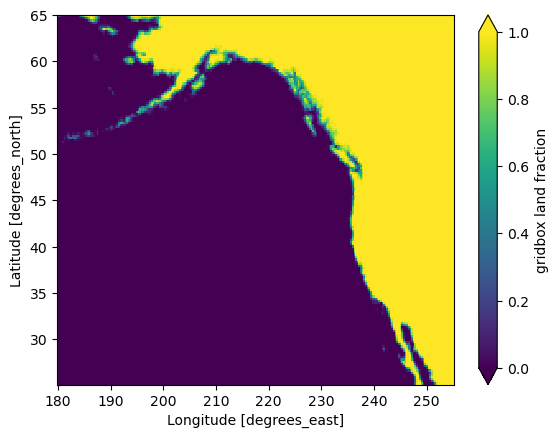

In [25]:
landfrac.plot(robust=True);

## Regional heatmap

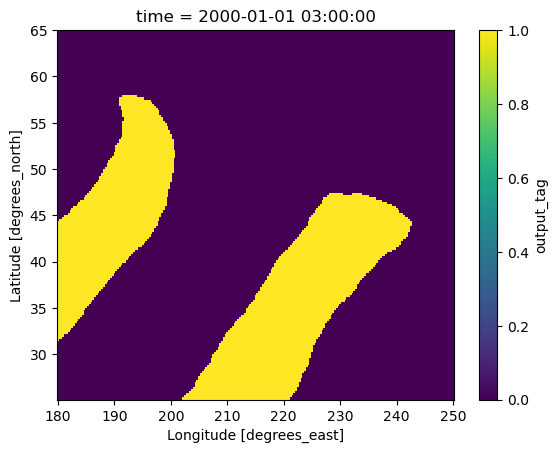

In [12]:
# set ARs = 1 and everything else 0
(cnet_timeshift.clip(min=1)-1).isel(time=0).plot();

In [23]:
AR = cnet_hist_rcp26.clip(min=1)-1
AR

<xarray.DataArray 'masks' (time: 46720, lat: 170, lon: 241)>
dask.array<sub, shape=(46720, 170, 241), dtype=int64, chunksize=(500, 170, 241), chunktype=numpy.ndarray>
Coordinates:
  * lon      (lon) float64 180.0 180.3 180.6 180.9 ... 254.1 254.4 254.7 255.0
  * lat      (lat) float64 25.23 25.46 25.7 25.93 ... 64.19 64.42 64.65 64.89
  * time     (time) object 2000-01-01 00:00:00 ... 2015-12-31 21:00:00

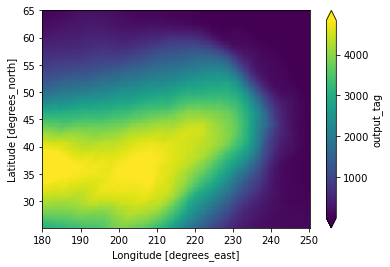

In [65]:
AR.sum(dim='time').plot(robust=True);

In [24]:
npercentARs = 100*(AR.sum(dim='time'))/len(cnet_hist_rcp26.time)
npercentARs

<xarray.DataArray 'masks' (lat: 170, lon: 241)>
dask.array<truediv, shape=(170, 241), dtype=float64, chunksize=(170, 241), chunktype=numpy.ndarray>
Coordinates:
  * lon      (lon) float64 180.0 180.3 180.6 180.9 ... 254.1 254.4 254.7 255.0
  * lat      (lat) float64 25.23 25.46 25.7 25.93 ... 64.19 64.42 64.65 64.89

In [25]:
npercentARs = npercentARs.persist()

In [34]:
npercentARs.max().values

array(27.11258562)

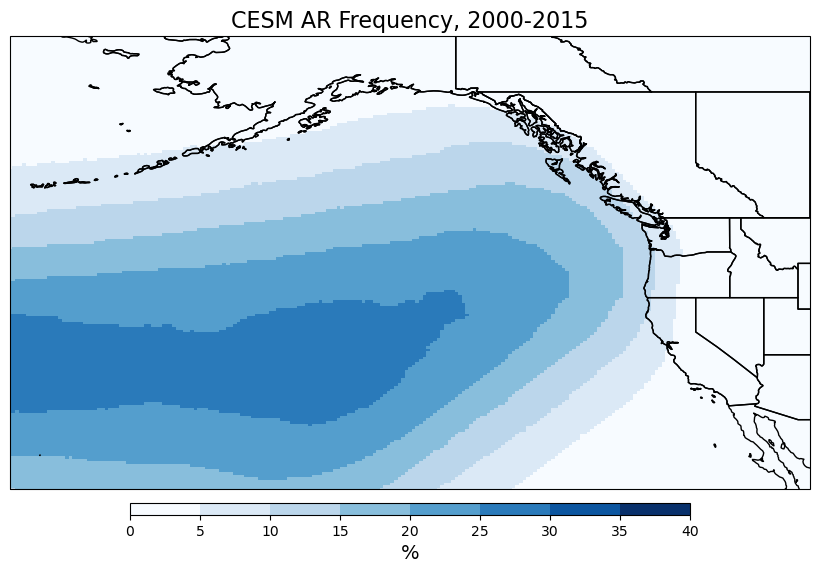

In [35]:
# a nicer plot
fig = plt.figure(figsize=(8,6))

cmap=plt.cm.get_cmap('Blues', 8)

ax = fig.add_axes([0.,0.,1.,1.], projection=ccrs.PlateCarree(central_longitude=180.0))

lat = npercentARs.lat
lon = npercentARs.lon
pc = ax.pcolormesh(lon, lat, npercentARs, cmap=cmap, vmin=0, vmax=40, transform=ccrs.PlateCarree())

# helps prevent white space at edges
ax.set_extent((lon[0],lon[-1],lat[0],lat[-1]), crs=ccrs.PlateCarree())

ax.coastlines(zorder=1)
ax.add_feature(cfeature.BORDERS, zorder=2) # duplicative?
ax.add_feature(cfeature.STATES, zorder=3)

# add colorbar
cbar_ax = fig.add_axes([0.15, 0.08, 0.7, 0.02])
cbar = plt.colorbar(pc, cax=cbar_ax, orientation='horizontal')
cbar.ax.set_xlabel('%', fontsize=14)

# add title
#ax.set_title('CESM AR Frequency, 2000-2005', fontsize=16); 
ax.set_title('CESM AR Frequency, 2000-2015', fontsize=16); 

#plt.savefig('../figures/toSCP/npercentARs_WUS_CESM_hist_rcp26.png', bbox_inches='tight')
#plt.savefig('../figures/toSCP/npercentARs_WUS_CESM_hist_rcp26_unwgt.png', bbox_inches='tight')

## Seasonal heatmaps

In [169]:
# getting the number of time points in each season (they vary due to month lengths)
season_lengths = cnet_hist_rcp26.time.groupby('time.season').count()
season_lengths

<xarray.DataArray 'time' (season: 4)>
array([11520, 11776, 11776, 11648])
Coordinates:
  * season   (season) object 'DJF' 'JJA' 'MAM' 'SON'

In [170]:
npercentARs_byseason = 100*((cnet_hist_rcp26.clip(min=1)-1).groupby('time.season').sum(dim='time'))/season_lengths
#npercentARs_byseason.sel(season='DJF').plot(robust=True);

In [171]:
npercentARs_byseason = npercentARs_byseason.persist()

In [34]:
npercentARs_byseason.max().values

array(46.18055556)

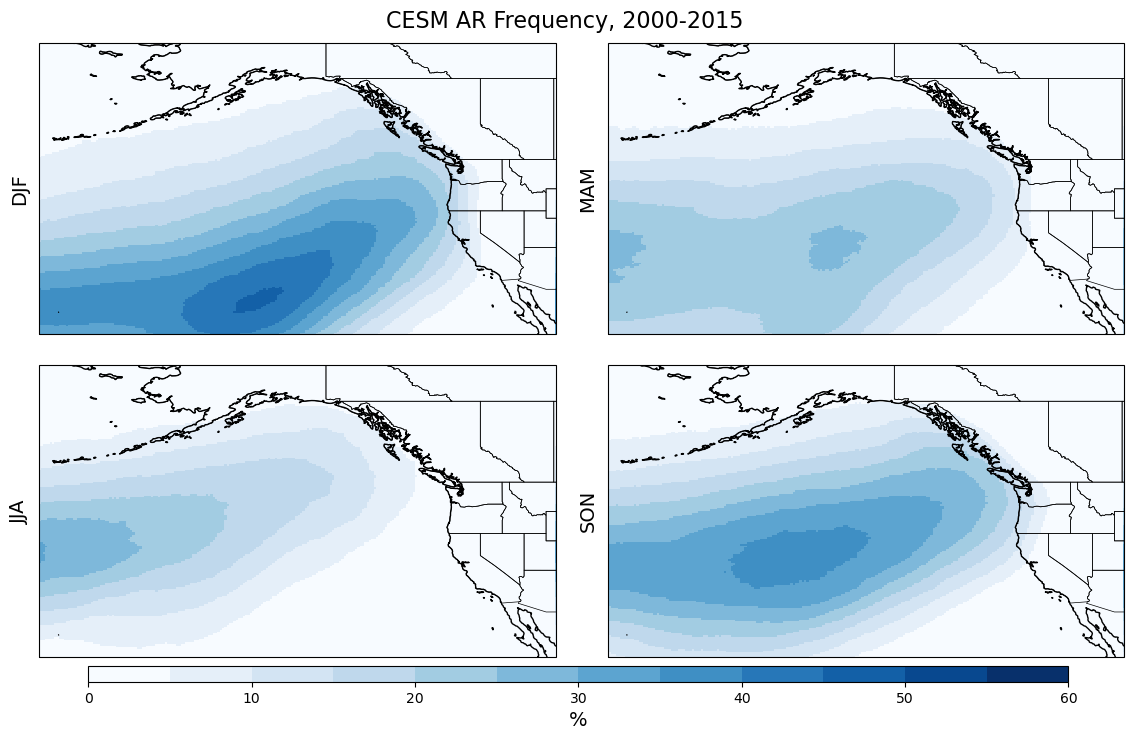

In [35]:
# a nicer plot
fig, axs = plt.subplots(2, 2, figsize=(14,8), subplot_kw={'projection': ccrs.PlateCarree(central_longitude=180.0)}) # ARTMIP region

axs = axs.ravel()

# discrete colormap
cmap=plt.cm.get_cmap('Blues', 12) # ARTMIP region

for i, season in enumerate(('DJF', 'MAM', 'JJA', 'SON')):
    field, lon = add_cyclic_point(npercentARs_byseason.sel(season=season), coord=npercentARs_byseason.lon)
    lat = npercentARs_byseason.lat
    cf = axs[i].pcolormesh(lon, lat, field, cmap=cmap, vmin=0, vmax=60, transform=ccrs.PlateCarree())
    axs[i].coastlines(zorder=1)
    axs[i].add_feature(cfeature.STATES, zorder=2, linewidth=0.5)
    axs[i].set_ylabel(season, fontsize=14)
    axs[i].set_yticks([])
    axs[i].set_extent((lon[0],lon[-1],lat[0],lat[-1]), crs=ccrs.PlateCarree())

# add colorbar
cb_ax = fig.add_axes([0.16, 0.08, 0.7, 0.02])
cbar = plt.colorbar(cf, cax=cb_ax, orientation='horizontal')
cbar.ax.set_xlabel('%', fontsize=14)

# add title
#fig.suptitle('CESM AR Frequency, 2000-2005', fontsize=16, y=0.92)
fig.suptitle('CESM AR Frequency, 2000-2015', fontsize=16, y=0.92)

plt.subplots_adjust(wspace=0.1, hspace=0.1)

#plt.savefig('../figures/toSCP/npercentARs_WUS_CESM_hist_byseason.png', bbox_inches='tight')
#plt.savefig('../figures/toSCP/npercentARs_WUS_CESM_hist_rcp26_byseason.png', bbox_inches='tight')
#plt.savefig('../figures/toSCP/npercentARs_WUS_CESM_hist_rcp26_byseason_unwgt.png', bbox_inches='tight')

## Monthly heatmaps/hovmollers

In [26]:
# getting the number of time points in each month
month_lengths = cnet_hist_rcp26.time.groupby('time.month').count()
month_lengths

<xarray.DataArray 'time' (month: 12)>
array([3968, 3584, 3968, 3840, 3968, 3840, 3968, 3968, 3840, 3968, 3840,
       3968])
Coordinates:
  * month    (month) int64 1 2 3 4 5 6 7 8 9 10 11 12

In [27]:
npercentARs_bymonth = 100*((cnet_hist_rcp26.clip(min=1)-1).groupby('time.month').sum(dim='time'))/month_lengths

In [ ]:
npercentARs_bymonth.sel(month=12).plot(robust=True);

In [28]:
npercentARs_bymonth = npercentARs_bymonth.persist()

In [29]:
npercentARs_bymonth.max().values

array(54.35987903)

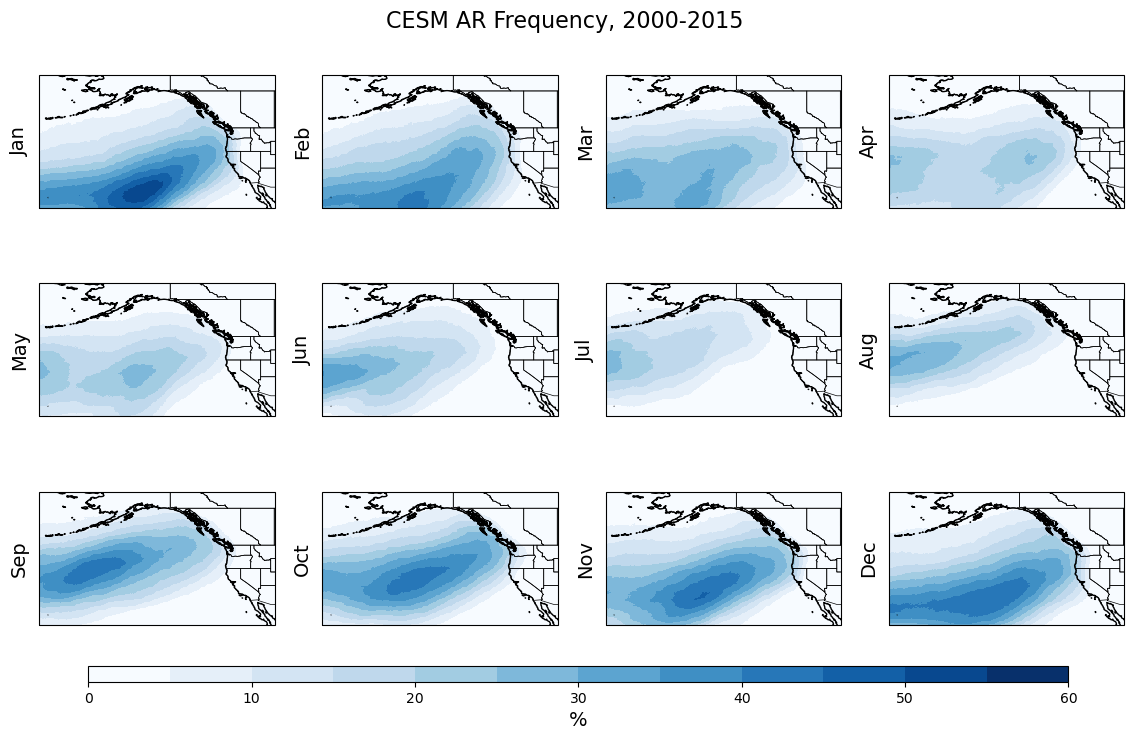

In [40]:
# a nicer plot
fig, axs = plt.subplots(3, 4, figsize=(14,8), subplot_kw={'projection': ccrs.PlateCarree(central_longitude=180.0)}) # ARTMIP region

axs = axs.ravel()

# discrete colormap
cmap=plt.cm.get_cmap('Blues', 12) # ARTMIP region

months = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

for i, m in enumerate(months):
    field, lon = add_cyclic_point(npercentARs_bymonth.sel(month=i+1), coord=npercentARs_bymonth.lon)
    lat = npercentARs_bymonth.lat
    cf = axs[i].pcolormesh(lon, lat, field, cmap=cmap, vmin=0, vmax=60, transform=ccrs.PlateCarree())
    axs[i].coastlines(zorder=1)
    axs[i].add_feature(cfeature.STATES, zorder=2, linewidth=0.5)
    axs[i].set_ylabel(m, fontsize=14)
    axs[i].set_yticks([])
    axs[i].set_extent((lon[0],lon[-1],lat[0],lat[-1]), crs=ccrs.PlateCarree())

# add colorbar
cb_ax = fig.add_axes([0.16, 0.08, 0.7, 0.02])
cbar = plt.colorbar(cf, cax=cb_ax, orientation='horizontal')
cbar.ax.set_xlabel('%', fontsize=14)

# add title
#fig.suptitle('CESM AR Frequency, 2000-2005', fontsize=16, y=0.92)
fig.suptitle('CESM AR Frequency, 2000-2015', fontsize=16, y=0.92)

plt.subplots_adjust(wspace=0.2, hspace=0.05)

#plt.savefig('../figures/toSCP/npercentARs_WUS_CESM_hist_rcp26_bymonth_unwgt.png', bbox_inches='tight')

## Zonal means by month for Hovmollers

In [29]:
#npercentARs_bymonth_zmean = npercentARs_bymonth.mean(dim='lon')
#npercentARs_bymonth_zmean = npercentARs_bymonth.sel(lon=slice(210,250)).mean(dim='lon')
npercentARs_bymonth_zmean = npercentARs_bymonth.sel(lon=slice(230,255)).mean(dim='lon') # same lons as counts at coastlines ARTMIP comparison
npercentARs_bymonth_zmean

<xarray.DataArray (month: 12, lat: 170)>
dask.array<mean_agg-aggregate, shape=(12, 170), dtype=float64, chunksize=(1, 170), chunktype=numpy.ndarray>
Coordinates:
  * lat      (lat) float64 25.23 25.46 25.7 25.93 ... 64.19 64.42 64.65 64.89
  * month    (month) int64 1 2 3 4 5 6 7 8 9 10 11 12

In [30]:
npercentARs_bymonth_zmean.max().values

array(9.4331815)

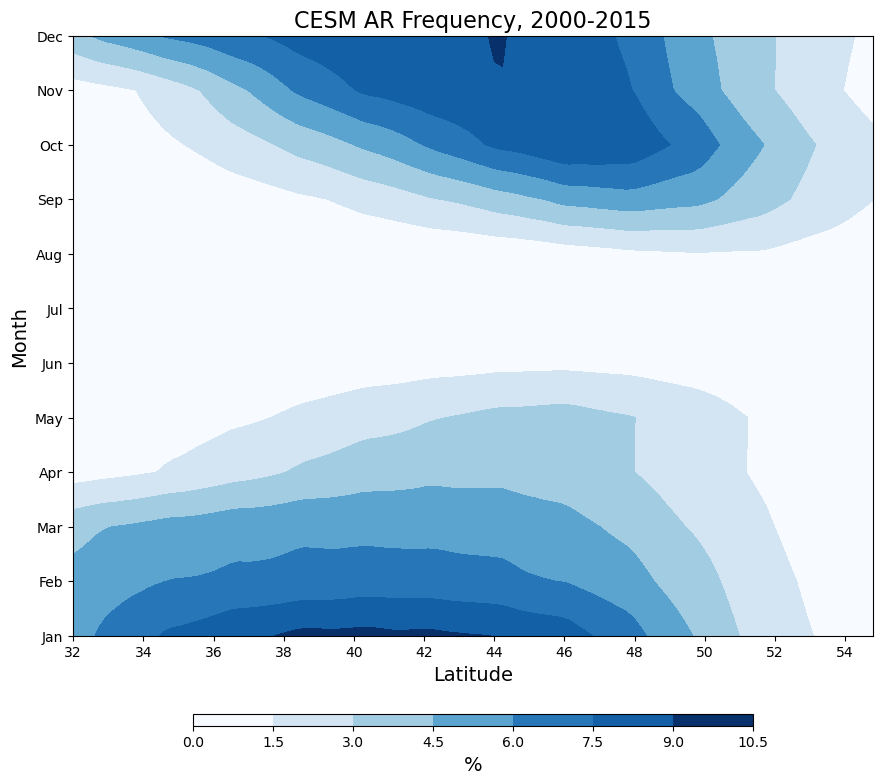

In [43]:
# a nicer plot
fig = plt.figure(figsize=(8,6))

cmap=plt.cm.get_cmap('Blues', 12)

ax = fig.add_axes([0.,0.,1.,1.])

#lat = npercentARs_bymonth_zmean.lat
lat = npercentARs_bymonth_zmean.lat.sel(lat=slice(32,55)) #artmip lats

mon = npercentARs_bymonth_zmean.month
# full WUS longitudes
#pc = ax.pcolormesh(mon, lat, npercentARs_bymonth_zmean.transpose(), cmap=cmap, vmin=0, vmax=30)
#pc = ax.contourf(mon, lat, npercentARs_bymonth_zmean.transpose(), cmap=cmap, vmin=0, vmax=30)
# restricted longitudes
#pc = ax.contourf(mon, lat, npercentARs_bymonth_zmean.transpose(), cmap=cmap, vmin=0, vmax=10)
# month x lat
pc = ax.contourf(lat, mon, npercentARs_bymonth_zmean.sel(lat=slice(32,55)), cmap=cmap, vmin=0, vmax=10)

# default is to order Jan-Dec from bottom to top
#ax.set_xticks(np.arange(12)+1, ['J','F','M','A','M','J','J','A','S','O','N','D'])
months = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
ax.set_yticks(np.arange(12)+1, months)

# July-June month ordering, y axis goes down in time -- still in progress to get this to work
# currently doesn't interpolate btw Dec-Jan and the data is flipped across the discontinuity
#mon_alt = xr.concat([npercentARs_bymonth_zmean.month.sel(month=slice(7,12)), npercentARs_bymonth_zmean.month.sel(month=slice(1,6))], dim='month')
#pc = ax.contourf(lat, mon_alt.isel(month=slice(None, None, -1)), npercentARs_bymonth_zmean.isel(month=slice(None, None, -1)).sel(lat=slice(32,55)), cmap=cmap, vmin=0, vmax=10) #month x lat
#months_alt = ['Jul','Aug','Sep','Oct','Nov','Dec','Jan','Feb','Mar','Apr','May','Jun']
#ax.set_yticks(np.arange(12)+1, months_alt[::-1])

ax.set_ylabel('Month', fontsize=14)

ax.set_xlabel('Latitude', fontsize=14)

# add more latitude labels
lat_labels = np.arange(32, 55, 2)
ax.set_xticks(lat_labels)

# add colorbar
cbar_ax = fig.add_axes([0.15, -0.15, 0.7, 0.02])
cbar = plt.colorbar(pc, cax=cbar_ax, orientation='horizontal')
cbar.ax.set_xlabel('%', fontsize=14)

# add title
ax.set_title('CESM AR Frequency, 2000-2015', fontsize=16); 

#plt.savefig('../figures/toSCP/npercentARs_WUS_CESM_hist_rcp26_bymonth_zmean.png', bbox_inches='tight')
#plt.savefig('../figures/toSCP/npercentARs_WUS_CESM_hist_rcp26_bymonth_zmean_artmip-lons.png', bbox_inches='tight')
#plt.savefig('../figures/toSCP/npercentARs_WUS_CESM_hist_rcp26_bymonth_zmean_artmip-lons-lats.png', bbox_inches='tight')

### Use landfrac to define coastal ARs
Are these longitude bounds too narrow? How to define "landfalling ARs"

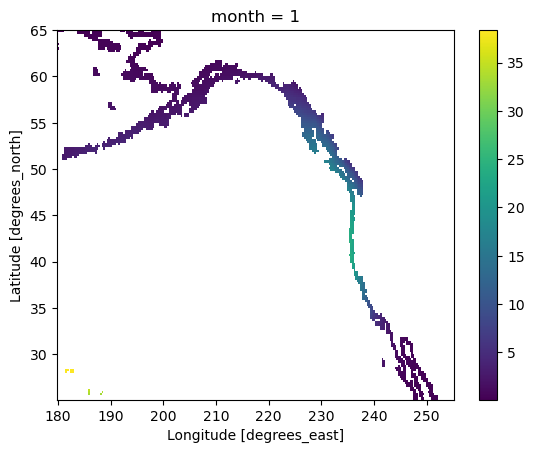

In [49]:
npercentARs_bymonth.where((landfrac > 0) & (landfrac < 0.99)).sel(month=1).plot();

In [32]:
npercentARs_bymonth_coastal_zmean = npercentARs_bymonth.where((landfrac > 0) & (landfrac < 0.99)).sel(lon=slice(230,255)).mean(dim='lon') # same lons as counts at coastlines ARTMIP comparison
npercentARs_bymonth_coastal_zmean

<xarray.DataArray (month: 12, lat: 170)>
dask.array<mean_agg-aggregate, shape=(12, 170), dtype=float64, chunksize=(1, 170), chunktype=numpy.ndarray>
Coordinates:
  * lat      (lat) float64 25.23 25.46 25.7 25.93 ... 64.19 64.42 64.65 64.89
  * month    (month) int64 1 2 3 4 5 6 7 8 9 10 11 12

In [33]:
npercentARs_bymonth_coastal_zmean.max().values

array(23.63071237)

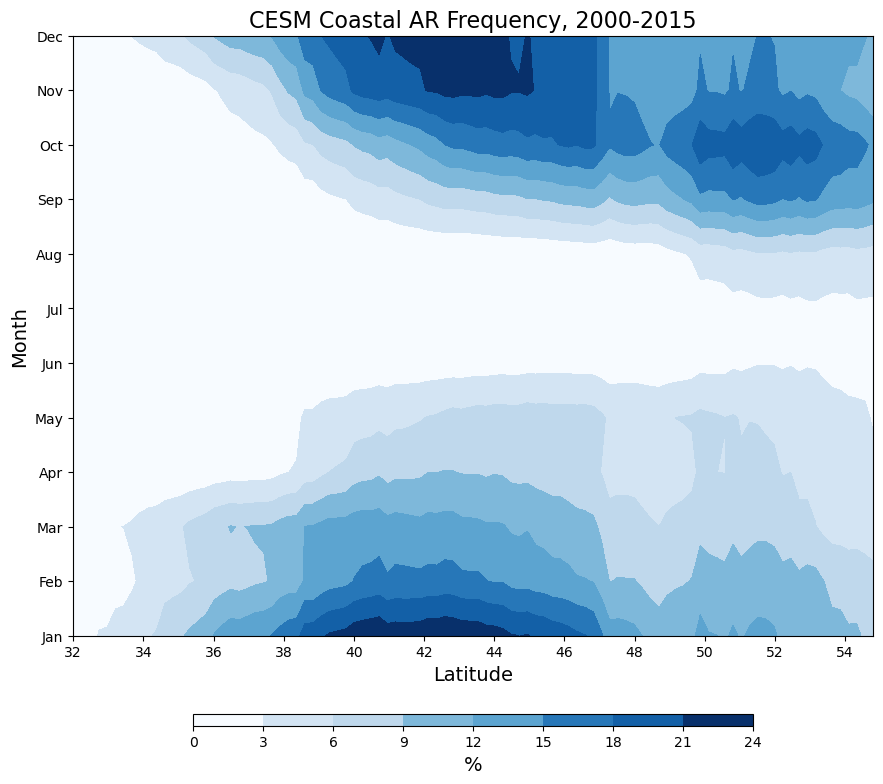

In [35]:
# a nicer plot
fig = plt.figure(figsize=(8,6))

cmap=plt.cm.get_cmap('Blues', 12)

ax = fig.add_axes([0.,0.,1.,1.])

lat = npercentARs_bymonth_coastal_zmean.lat.sel(lat=slice(32,55)) #artmip lats

mon = npercentARs_bymonth_coastal_zmean.month
# month x lat
pc = ax.contourf(lat, mon, npercentARs_bymonth_coastal_zmean.sel(lat=slice(32,55)), cmap=cmap, vmin=0, vmax=24)

# default is to order Jan-Dec from bottom to top
#ax.set_xticks(np.arange(12)+1, ['J','F','M','A','M','J','J','A','S','O','N','D'])
months = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
ax.set_yticks(np.arange(12)+1, months)

ax.set_ylabel('Month', fontsize=14)

ax.set_xlabel('Latitude', fontsize=14)

# add more latitude labels
lat_labels = np.arange(32, 55, 2)
ax.set_xticks(lat_labels)

# add colorbar
cbar_ax = fig.add_axes([0.15, -0.15, 0.7, 0.02])
cbar = plt.colorbar(pc, cax=cbar_ax, orientation='horizontal')
cbar.ax.set_xlabel('%', fontsize=14)

# add title
ax.set_title('CESM Coastal AR Frequency, 2000-2015', fontsize=16); 

#plt.savefig('../figures/toSCP/npercentARs_WUS_CESM_hist_rcp26_bymonth_coastal_zmean_artmip-lons-lats.png', bbox_inches='tight')

## RCP8.5

In [36]:
AR_rcp85 = cnet_rcp85.clip(min=1)-1

In [26]:
npercentARs_rcp85 = 100*(AR_rcp85.sum(dim='time'))/len(cnet_rcp85.time)
npercentARs_rcp85

<xarray.DataArray 'masks' (lat: 170, lon: 241)>
dask.array<truediv, shape=(170, 241), dtype=float64, chunksize=(170, 241), chunktype=numpy.ndarray>
Coordinates:
  * lat      (lat) float64 25.23 25.46 25.7 25.93 ... 64.19 64.42 64.65 64.89
  * lon      (lon) float64 180.0 180.3 180.6 180.9 ... 254.1 254.4 254.7 255.0

In [179]:
npercentARs_rcp85 = npercentARs_rcp85.persist()

In [145]:
npercentARs_rcp85.max().values

array(25.59360731)

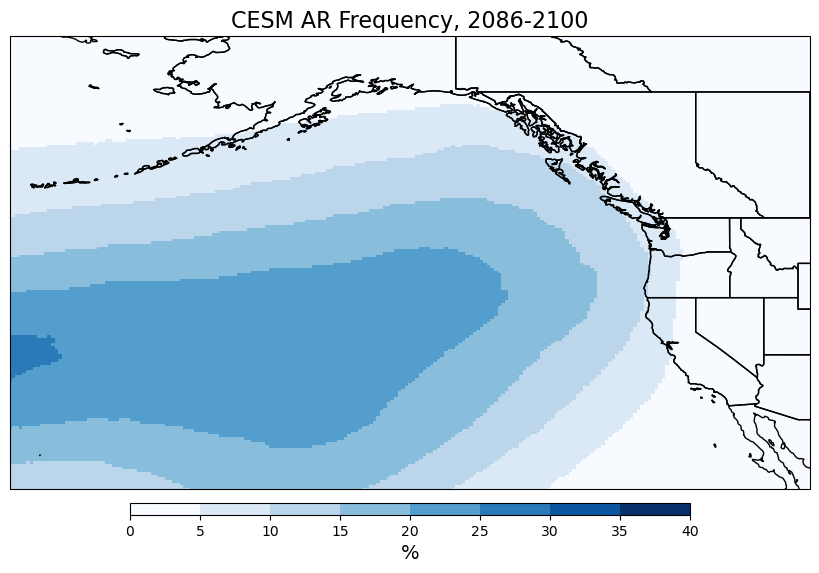

In [146]:
# a nicer plot
fig = plt.figure(figsize=(8,6))

cmap=plt.cm.get_cmap('Blues', 8)

ax = fig.add_axes([0.,0.,1.,1.], projection=ccrs.PlateCarree(central_longitude=180.0))

lat = npercentARs_rcp85.lat
lon = npercentARs_rcp85.lon
pc = ax.pcolormesh(lon, lat, npercentARs_rcp85, cmap=cmap, vmin=0, vmax=40, transform=ccrs.PlateCarree())

# helps prevent white space at edges
ax.set_extent((lon[0],lon[-1],lat[0],lat[-1]), crs=ccrs.PlateCarree())

ax.coastlines(zorder=1)
ax.add_feature(cfeature.BORDERS, zorder=2) # duplicative?
ax.add_feature(cfeature.STATES, zorder=3)

# add colorbar
cbar_ax = fig.add_axes([0.15, 0.08, 0.7, 0.02])
cbar = plt.colorbar(pc, cax=cbar_ax, orientation='horizontal')
cbar.ax.set_xlabel('%', fontsize=14)

# add title
ax.set_title('CESM AR Frequency, 2086-2100', fontsize=16); 

In [180]:
# getting the number of time points in each season (they vary due to month lengths)
season_lengths_rcp85 = cnet_rcp85.time.groupby('time.season').count()
season_lengths_rcp85

<xarray.DataArray 'time' (season: 4)>
array([10800, 11040, 11040, 10920])
Coordinates:
  * season   (season) object 'DJF' 'JJA' 'MAM' 'SON'
Attributes:
    standard_name:  time
    long_name:      time
    axis:           T
    bounds:         time_bnds

In [181]:
npercentARs_byseason_rcp85 = 100*((cnet_rcp85.clip(min=1)-1).groupby('time.season').sum(dim='time'))/season_lengths_rcp85

In [182]:
npercentARs_byseason_rcp85 = npercentARs_byseason_rcp85.persist()

In [37]:
npercentARs_byseason_rcp85.max().values

array(35.99074074)

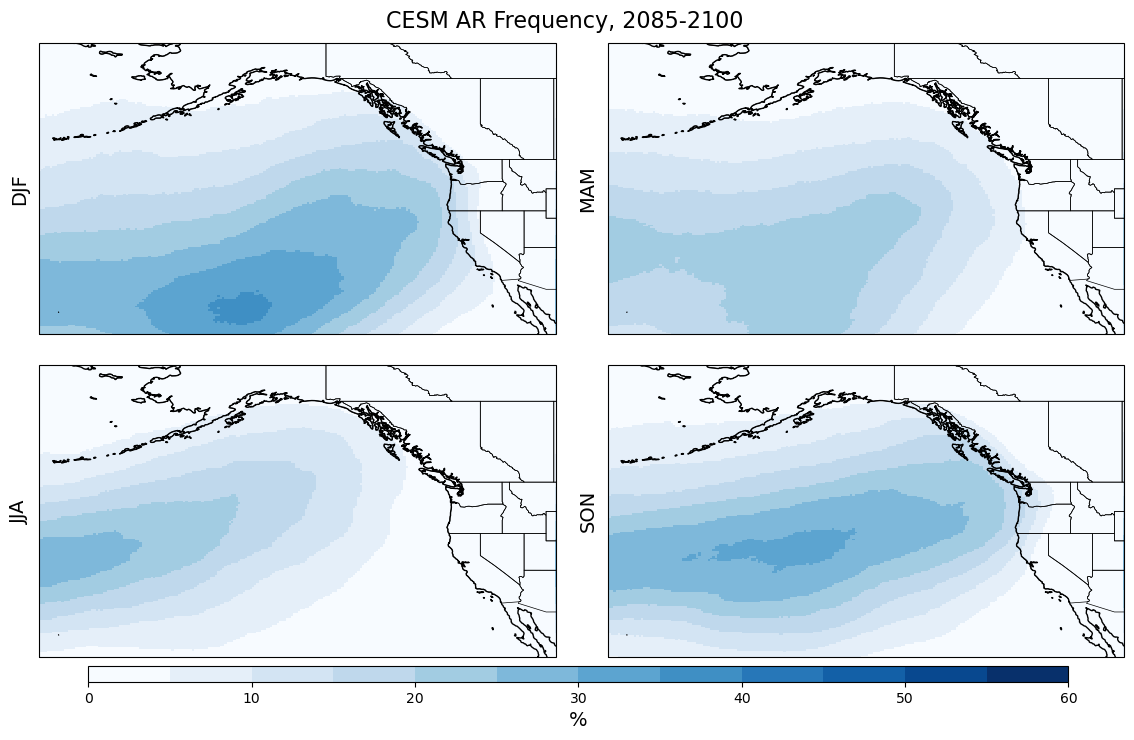

In [38]:
# a nicer plot
fig, axs = plt.subplots(2, 2, figsize=(14,8), subplot_kw={'projection': ccrs.PlateCarree(central_longitude=180.0)}) # ARTMIP region

axs = axs.ravel()

# discrete colormap
cmap=plt.cm.get_cmap('Blues', 12) # ARTMIP region

for i, season in enumerate(('DJF', 'MAM', 'JJA', 'SON')):
    field, lon = add_cyclic_point(npercentARs_byseason_rcp85.sel(season=season), coord=npercentARs_byseason_rcp85.lon)
    lat = npercentARs_byseason_rcp85.lat
    cf = axs[i].pcolormesh(lon, lat, field, cmap=cmap, vmin=0, vmax=60, transform=ccrs.PlateCarree())
    axs[i].coastlines(zorder=1)
    axs[i].add_feature(cfeature.STATES, zorder=2, linewidth=0.5)
    axs[i].set_ylabel(season, fontsize=14)
    axs[i].set_yticks([])
    axs[i].set_extent((lon[0],lon[-1],lat[0],lat[-1]), crs=ccrs.PlateCarree())

# add colorbar
cb_ax = fig.add_axes([0.16, 0.08, 0.7, 0.02])
cbar = plt.colorbar(cf, cax=cb_ax, orientation='horizontal')
cbar.ax.set_xlabel('%', fontsize=14)

# add title
fig.suptitle('CESM AR Frequency, 2085-2100', fontsize=16, y=0.92) ### TYPO HERE - should be 2086-2100

plt.subplots_adjust(wspace=0.1, hspace=0.1)

#plt.savefig('../figures/toSCP/npercentARs_WUS_CESM_rcp85_byseason_unwgt.png', bbox_inches='tight')
#plt.savefig('../figures/toSCP/npercentARs_WUS_CESM_rcp85_byseason_config.png', bbox_inches='tight')

In [37]:
# getting the number of time points in each month
month_lengths_rcp85 = cnet_rcp85.time.groupby('time.month').count()
month_lengths_rcp85

<xarray.DataArray 'time' (month: 12)>
array([3720, 3360, 3720, 3600, 3720, 3600, 3720, 3720, 3600, 3720, 3600,
       3720])
Coordinates:
  * month    (month) int64 1 2 3 4 5 6 7 8 9 10 11 12
Attributes:
    standard_name:  time
    long_name:      time
    axis:           T
    bounds:         time_bnds

In [38]:
npercentARs_bymonth_rcp85 = 100*((cnet_rcp85.clip(min=1)-1).groupby('time.month').sum(dim='time'))/month_lengths_rcp85

In [39]:
npercentARs_bymonth_rcp85 = npercentARs_bymonth_rcp85.persist()

In [42]:
npercentARs_bymonth_rcp85.max().values

array(41.0483871)

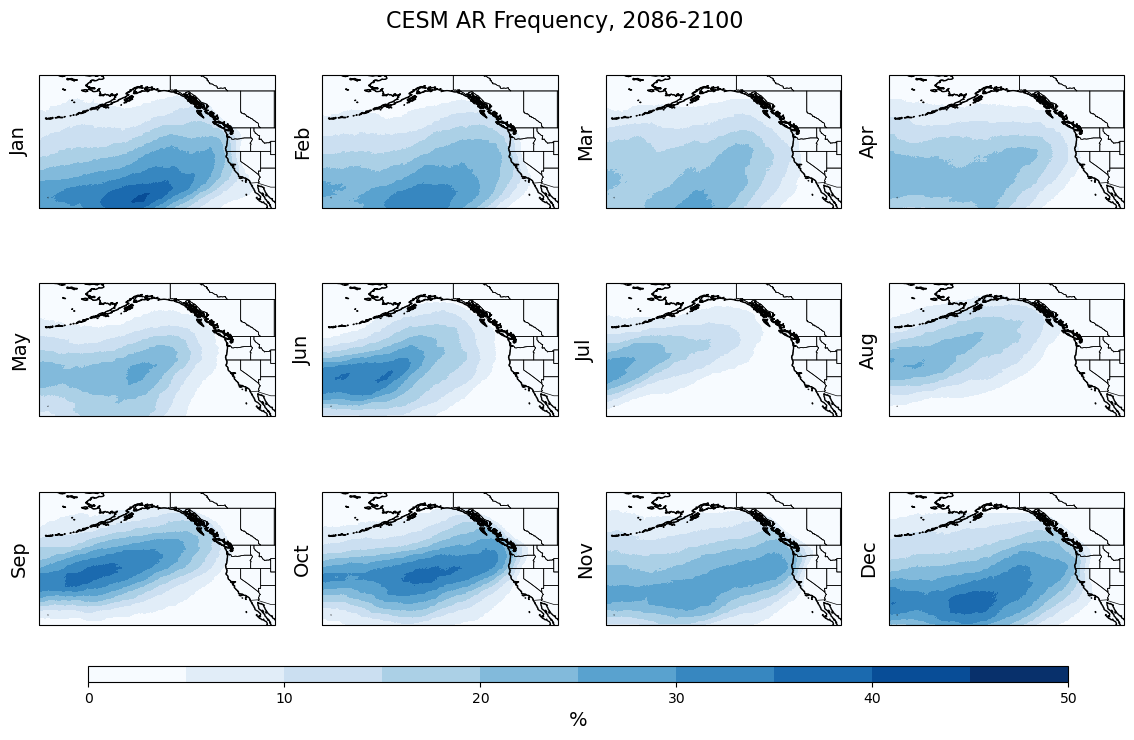

In [43]:
# a nicer plot
fig, axs = plt.subplots(3, 4, figsize=(14,8), subplot_kw={'projection': ccrs.PlateCarree(central_longitude=180.0)}) # ARTMIP region

axs = axs.ravel()

# discrete colormap
cmap=plt.cm.get_cmap('Blues', 10) # ARTMIP region

months = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

for i, m in enumerate(months):
    field, lon = add_cyclic_point(npercentARs_bymonth_rcp85.sel(month=i+1), coord=npercentARs_bymonth_rcp85.lon)
    lat = npercentARs_bymonth_rcp85.lat
    cf = axs[i].pcolormesh(lon, lat, field, cmap=cmap, vmin=0, vmax=50, transform=ccrs.PlateCarree())
    axs[i].coastlines(zorder=1)
    axs[i].add_feature(cfeature.STATES, zorder=2, linewidth=0.5)
    axs[i].set_ylabel(m, fontsize=14)
    axs[i].set_yticks([])
    axs[i].set_extent((lon[0],lon[-1],lat[0],lat[-1]), crs=ccrs.PlateCarree())

# add colorbar
cb_ax = fig.add_axes([0.16, 0.08, 0.7, 0.02])
cbar = plt.colorbar(cf, cax=cb_ax, orientation='horizontal')
cbar.ax.set_xlabel('%', fontsize=14)

# add title
fig.suptitle('CESM AR Frequency, 2086-2100', fontsize=16, y=0.92)

plt.subplots_adjust(wspace=0.2, hspace=0.05)

#plt.savefig('../figures/toSCP/npercentARs_WUS_CESM_rcp85_bymonth_unwgt.png', bbox_inches='tight')
#plt.savefig('../figures/toSCP/npercentARs_WUS_CESM_rcp85_bymonth_config.png', bbox_inches='tight')

In [48]:
#npercentARs_bymonth_zmean_rcp85 = npercentARs_bymonth_rcp85.mean(dim='lon')
#npercentARs_bymonth_zmean_rcp85 = npercentARs_bymonth_rcp85.sel(lon=slice(210,250)).mean(dim='lon')
npercentARs_bymonth_zmean_rcp85 = npercentARs_bymonth_rcp85.sel(lon=slice(230,255)).mean(dim='lon') # same lons as counts at coastlines ARTMIP comparison
npercentARs_bymonth_zmean_rcp85

<xarray.DataArray (month: 12, lat: 170)>
dask.array<mean_agg-aggregate, shape=(12, 170), dtype=float64, chunksize=(1, 170), chunktype=numpy.ndarray>
Coordinates:
  * lat      (lat) float64 25.23 25.46 25.7 25.93 ... 64.19 64.42 64.65 64.89
  * month    (month) int64 1 2 3 4 5 6 7 8 9 10 11 12

In [49]:
npercentARs_bymonth_zmean_rcp85.max().values

array(10.2392805)

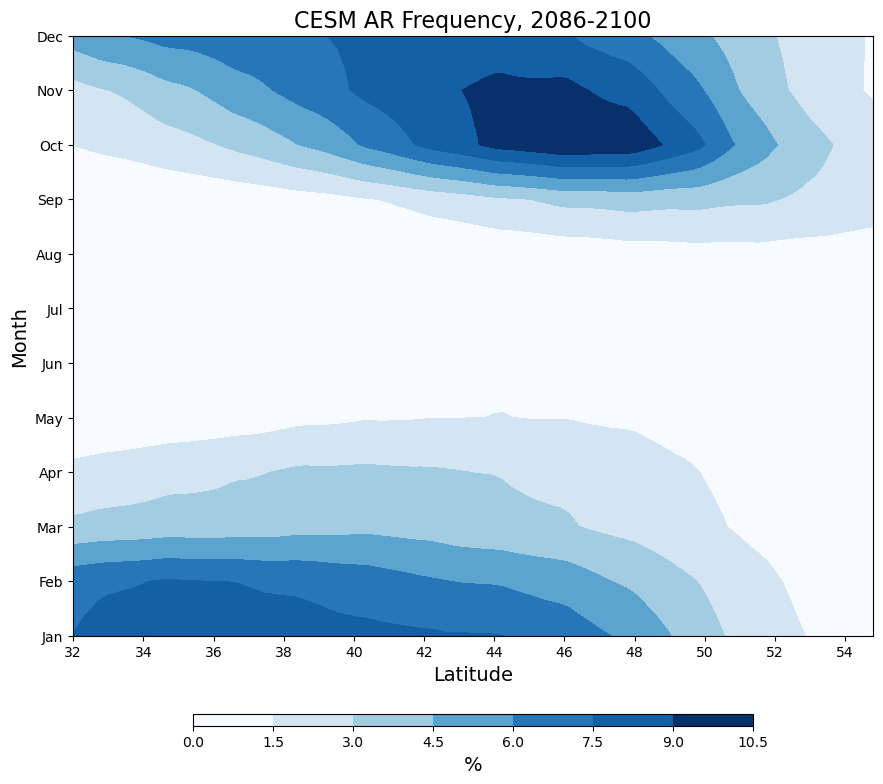

In [53]:
# a nicer plot
fig = plt.figure(figsize=(8,6))

cmap=plt.cm.get_cmap('Blues', 12)

ax = fig.add_axes([0.,0.,1.,1.])

#lat = npercentARs_bymonth_zmean_rcp85.lat
lat = npercentARs_bymonth_zmean_rcp85.lat.sel(lat=slice(32,55)) #artmip lats

mon = npercentARs_bymonth_zmean_rcp85.month
# full WUS longitudes
#pc = ax.pcolormesh(mon, lat, npercentARs_bymonth_zmean_rcp85.transpose(), cmap=cmap, vmin=0, vmax=30)
#pc = ax.contourf(mon, lat, npercentARs_bymonth_zmean_rcp85.transpose(), cmap=cmap, vmin=0, vmax=30)
# restricted longitudes
#pc = ax.contourf(mon, lat, npercentARs_bymonth_zmean_rcp85.transpose(), cmap=cmap, vmin=0, vmax=14)
# month x lat
pc = ax.contourf(lat, mon, npercentARs_bymonth_zmean_rcp85.sel(lat=slice(32,55)), cmap=cmap, vmin=0, vmax=10)


# default is to order Jan-Dec from bottom to top
#ax.set_xticks(np.arange(12)+1, ['J','F','M','A','M','J','J','A','S','O','N','D'])
months = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
ax.set_yticks(np.arange(12)+1, months)

ax.set_ylabel('Month', fontsize=14)

ax.set_xlabel('Latitude', fontsize=14)

# add more latitude labels
lat_labels = np.arange(32, 55, 2)
ax.set_xticks(lat_labels)

# add colorbar
cbar_ax = fig.add_axes([0.15, -0.15, 0.7, 0.02])
cbar = plt.colorbar(pc, cax=cbar_ax, orientation='horizontal')
cbar.ax.set_xlabel('%', fontsize=14)

# add title
ax.set_title('CESM AR Frequency, 2086-2100', fontsize=16); 

#plt.savefig('../figures/toSCP/npercentARs_WUS_CESM_rcp85_bymonth_zmean.png', bbox_inches='tight')
#plt.savefig('../figures/toSCP/npercentARs_WUS_CESM_rcp85_bymonth_zmean_config.png', bbox_inches='tight')
#plt.savefig('../figures/toSCP/npercentARs_WUS_CESM_rcp85_bymonth_zmean_config_artmip-lons-lats.png', bbox_inches='tight')

### Coastal ARs

In [40]:
npercentARs_bymonth_coastal_zmean_rcp85 = npercentARs_bymonth_rcp85.where((landfrac > 0) & (landfrac < 0.99)).sel(lon=slice(230,255)).mean(dim='lon') # same lons as counts at coastlines ARTMIP comparison
npercentARs_bymonth_coastal_zmean_rcp85

<xarray.DataArray (month: 12, lat: 170)>
dask.array<mean_agg-aggregate, shape=(12, 170), dtype=float64, chunksize=(1, 170), chunktype=numpy.ndarray>
Coordinates:
  * lat      (lat) float64 25.23 25.46 25.7 25.93 ... 64.19 64.42 64.65 64.89
  * month    (month) int64 1 2 3 4 5 6 7 8 9 10 11 12

In [41]:
npercentARs_bymonth_coastal_zmean_rcp85.max().values

array(23.02777778)

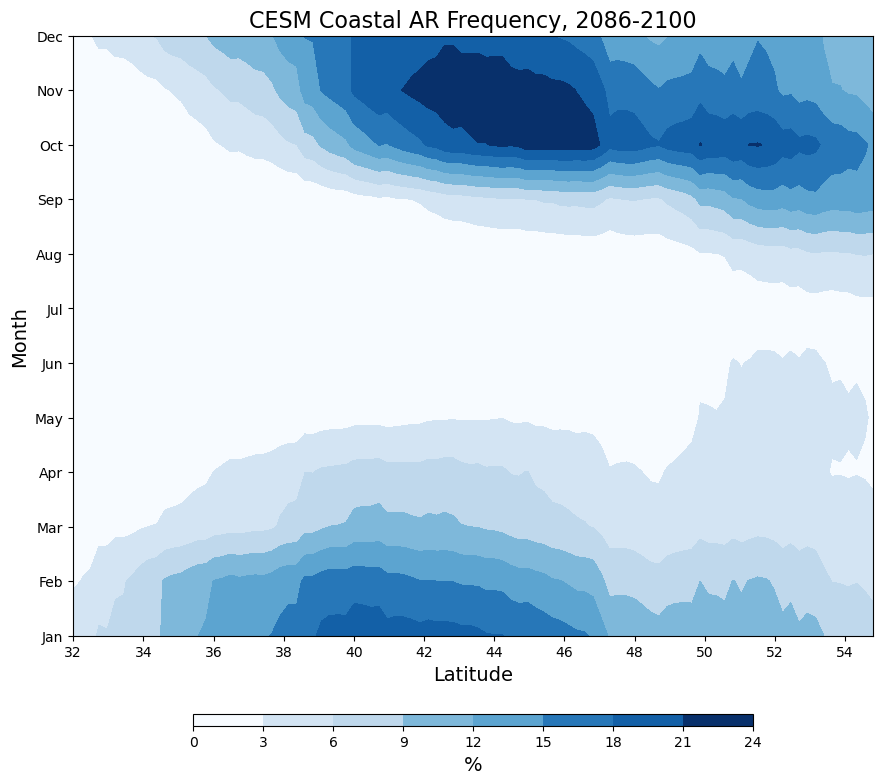

In [44]:
# a nicer plot
fig = plt.figure(figsize=(8,6))

cmap=plt.cm.get_cmap('Blues', 12)

ax = fig.add_axes([0.,0.,1.,1.])

lat = npercentARs_bymonth_coastal_zmean_rcp85.lat.sel(lat=slice(32,55)) #artmip lats

mon = npercentARs_bymonth_coastal_zmean_rcp85.month
# month x lat
pc = ax.contourf(lat, mon, npercentARs_bymonth_coastal_zmean_rcp85.sel(lat=slice(32,55)), cmap=cmap, vmin=0, vmax=24)

# default is to order Jan-Dec from bottom to top
#ax.set_xticks(np.arange(12)+1, ['J','F','M','A','M','J','J','A','S','O','N','D'])
months = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
ax.set_yticks(np.arange(12)+1, months)

ax.set_ylabel('Month', fontsize=14)

ax.set_xlabel('Latitude', fontsize=14)

# add more latitude labels
lat_labels = np.arange(32, 55, 2)
ax.set_xticks(lat_labels)

# add colorbar
cbar_ax = fig.add_axes([0.15, -0.15, 0.7, 0.02])
cbar = plt.colorbar(pc, cax=cbar_ax, orientation='horizontal')
cbar.ax.set_xlabel('%', fontsize=14)

# add title
ax.set_title('CESM Coastal AR Frequency, 2086-2100', fontsize=16); 

#plt.savefig('../figures/toSCP/npercentARs_WUS_CESM_rcp85_bymonth_coastal_zmean_artmip-lons-lats.png', bbox_inches='tight')

## Diffs

In [188]:
npercentARs_diff = npercentARs_rcp85 - npercentARs

In [189]:
print(npercentARs_diff.min().values,
      npercentARs_diff.max().values)

-5.037671232876713 2.0659246575342465


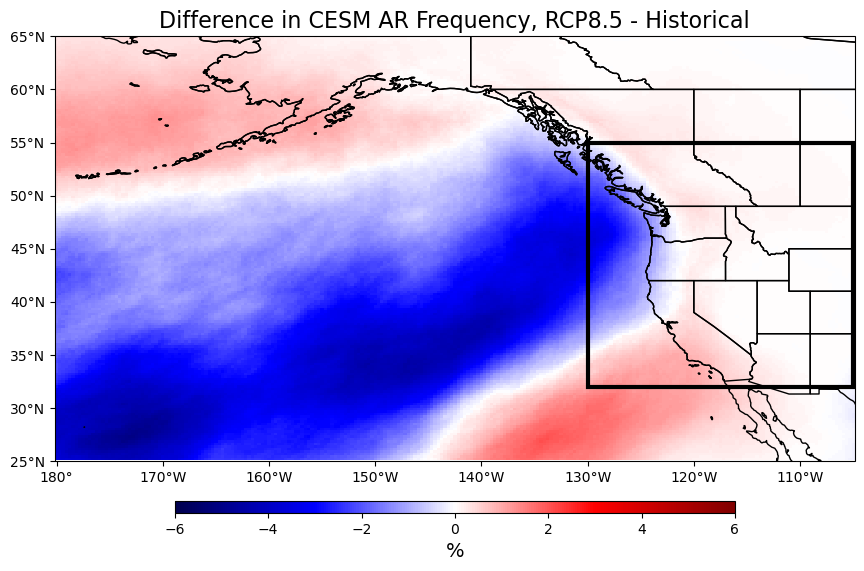

In [229]:
fig = plt.figure(figsize=(8,6))

cmap=plt.cm.get_cmap('seismic')

ax = fig.add_axes([0.,0.,1.,1.], projection=ccrs.PlateCarree(central_longitude=180.0))

lat = npercentARs_diff.lat
lon = npercentARs_diff.lon
pc = ax.pcolormesh(lon, lat, npercentARs_diff, cmap=cmap, vmin=-6, vmax=6, transform=ccrs.PlateCarree())

# helps prevent white space at edges
#ax.set_extent((lon[0],lon[-1],lat[0],lat[-1]), crs=ccrs.PlateCarree())

ax.coastlines(zorder=1)
#ax.add_feature(cfeature.BORDERS, zorder=2) # duplicative?
ax.add_feature(cfeature.STATES, zorder=3)

# add box for hovmoller plot reference
#lon=slice(230,255) # artmip
#lat_bounds = slice(32,55) # counts at coastlines
ax.add_patch(mpatches.Rectangle(xy=[230, 32], width=25, height=23,
                                facecolor='none', edgecolor='k',
                                linewidth=3,
                                transform=ccrs.PlateCarree()))

# add lat/lon labels (not sure why cartopy doesn't do this automatically?)
lon_labels = np.arange(180, 256, 10) 
ax.set_xticks(lon_labels, crs=ccrs.PlateCarree()) # crs setting is important for central_longitude=180
ax.set_xticklabels(lon_labels) # but you also need to label explicitly
lat_labels = np.arange(25, 66, 5) # this works ok
ax.set_yticks(lat_labels)

# lat/lon formatters to add degrees
lon_formatter = cticker.LongitudeFormatter()
lat_formatter = cticker.LatitudeFormatter()
ax.xaxis.set_major_formatter(lon_formatter)
ax.yaxis.set_major_formatter(lat_formatter)
#ax.grid(linewidth=2, color='black', alpha=0.5, linestyle='--') # optional gridlines

# alternative gridlines option
#ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.7, color='gray', alpha=0.5, linestyle='--', dms=True)

# add colorbar
cbar_ax = fig.add_axes([0.15, 0.06, 0.7, 0.02])
cbar = plt.colorbar(pc, cax=cbar_ax, orientation='horizontal')
cbar.ax.set_xlabel('%', fontsize=14)

# add title
ax.set_title('Difference in CESM AR Frequency, RCP8.5 - Historical', fontsize=16); 

#plt.savefig('../figures/toSCP/npercentARs_WUS_CESM_diff_withbox.png', bbox_inches='tight')

In [193]:
npercentARs_byseason_diff = npercentARs_byseason_rcp85 - npercentARs_byseason

In [194]:
print(npercentARs_byseason_diff.min().values,
      npercentARs_byseason_diff.max().values)

-11.78993055555555 4.281249999999999


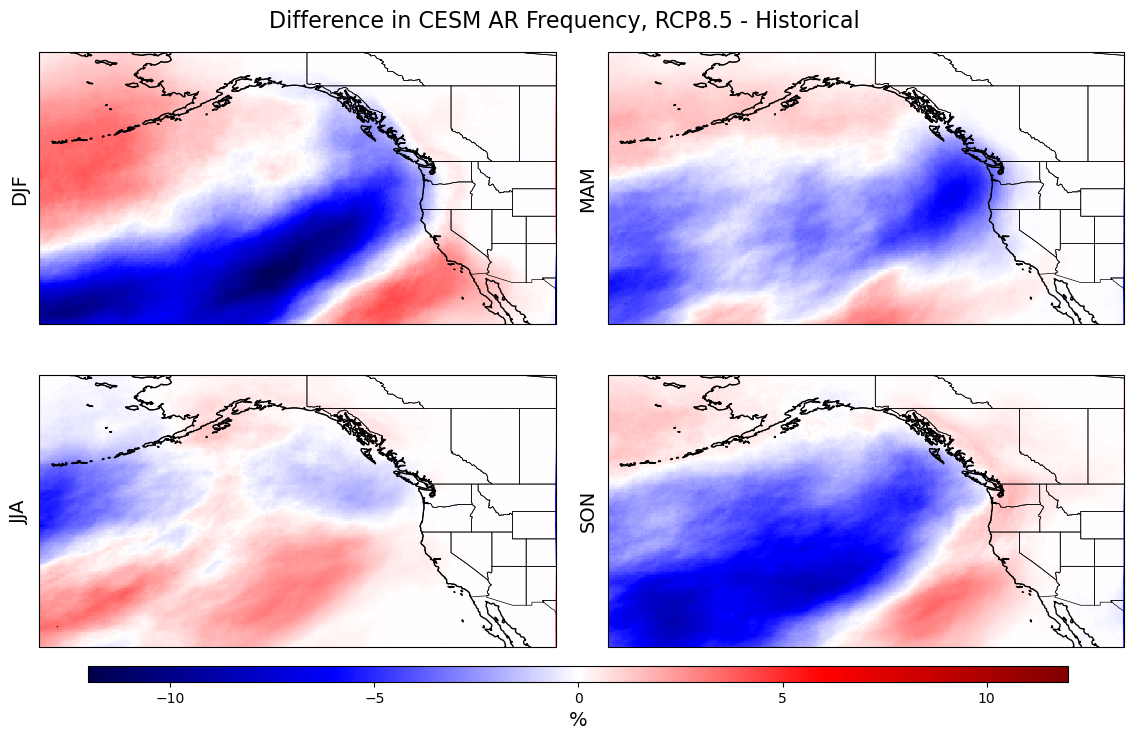

In [195]:
fig, axs = plt.subplots(2, 2, figsize=(14,8), subplot_kw={'projection': ccrs.PlateCarree(central_longitude=180.0)}) # ARTMIP region

axs = axs.ravel()

cmap=plt.cm.get_cmap('seismic')

for i, season in enumerate(('DJF', 'MAM', 'JJA', 'SON')):
    field, lon = add_cyclic_point(npercentARs_byseason_diff.sel(season=season), coord=npercentARs_byseason_diff.lon)
    lat = npercentARs_byseason_diff.lat
    cf = axs[i].pcolormesh(lon, lat, field, cmap=cmap, vmin=-12, vmax=12, transform=ccrs.PlateCarree())
    axs[i].coastlines(zorder=1)
    axs[i].add_feature(cfeature.STATES, zorder=2, linewidth=0.5)
    axs[i].set_ylabel(season, fontsize=14)
    axs[i].set_yticks([])
    axs[i].set_extent((lon[0],lon[-1],lat[0],lat[-1]), crs=ccrs.PlateCarree())

# add colorbar
cb_ax = fig.add_axes([0.16, 0.08, 0.7, 0.02])
cbar = plt.colorbar(cf, cax=cb_ax, orientation='horizontal')
cbar.ax.set_xlabel('%', fontsize=14)

# add title
fig.suptitle('Difference in CESM AR Frequency, RCP8.5 - Historical', fontsize=16, y=0.92)

plt.subplots_adjust(wspace=0.1, hspace=0.1)

#plt.savefig('../figures/toSCP/npercentARs_WUS_CESM_diff_byseason_unwgt.png', bbox_inches='tight')
#plt.savefig('../figures/toSCP/npercentARs_WUS_CESM_diff_byseason_unwgt_config.png', bbox_inches='tight')

In [196]:
npercentARs_bymonth_diff = npercentARs_bymonth_rcp85 - npercentARs_bymonth

In [197]:
print(npercentARs_bymonth_diff.min().values,
      npercentARs_bymonth_diff.max().values)

-17.815972222222225 13.645833333333332


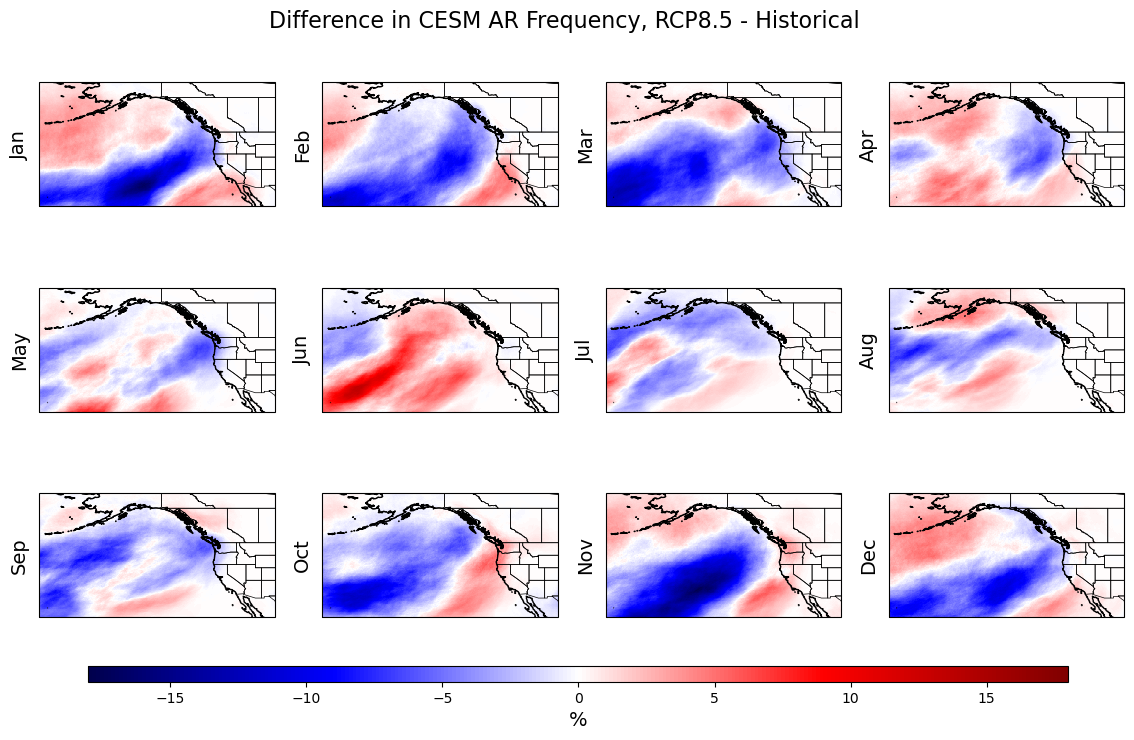

In [198]:
# a nicer plot
fig, axs = plt.subplots(3, 4, figsize=(14,8), subplot_kw={'projection': ccrs.PlateCarree(central_longitude=180.0)}) # ARTMIP region

axs = axs.ravel()

cmap=plt.cm.get_cmap('seismic')

months = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

for i, m in enumerate(months):
    field, lon = add_cyclic_point(npercentARs_bymonth_diff.sel(month=i+1), coord=npercentARs_bymonth_diff.lon)
    lat = npercentARs_bymonth_diff.lat
    cf = axs[i].pcolormesh(lon, lat, field, cmap=cmap, vmin=-18, vmax=18, transform=ccrs.PlateCarree())
    axs[i].coastlines(zorder=1)
    axs[i].add_feature(cfeature.STATES, zorder=2, linewidth=0.5)
    axs[i].set_ylabel(m, fontsize=14)
    axs[i].set_yticks([])
    axs[i].set_extent((lon[0],lon[-1],lat[0],lat[-1]), crs=ccrs.PlateCarree())

# add colorbar
cb_ax = fig.add_axes([0.16, 0.08, 0.7, 0.02])
cbar = plt.colorbar(cf, cax=cb_ax, orientation='horizontal')
cbar.ax.set_xlabel('%', fontsize=14)

# add title
fig.suptitle('Difference in CESM AR Frequency, RCP8.5 - Historical', fontsize=16, y=0.92)

plt.subplots_adjust(wspace=0.2, hspace=0)

#plt.savefig('../figures/toSCP/npercentARs_WUS_CESM_diff_bymonth_unwgt.png', bbox_inches='tight')
#plt.savefig('../figures/toSCP/npercentARs_WUS_CESM_diff_bymonth_unwgt_config.png', bbox_inches='tight')

In [199]:
npercentARs_bymonth_zmean_diff = npercentARs_bymonth_zmean_rcp85 - npercentARs_bymonth_zmean

In [200]:
print(npercentARs_bymonth_zmean_diff.min().values,
      npercentARs_bymonth_zmean_diff.max().values)

-2.1167902893933364 2.573696568432231


### Trying to get the July - June ordering

In [74]:
xr.concat([npercentARs_bymonth_zmean_rcp85.month.sel(month=slice(7,12)), npercentARs_bymonth_zmean_rcp85.month.sel(month=slice(1,6))], dim='month')

<xarray.DataArray 'month' (month: 12)>
array([ 7,  8,  9, 10, 11, 12,  1,  2,  3,  4,  5,  6])
Coordinates:
  * month    (month) int64 7 8 9 10 11 12 1 2 3 4 5 6

In [75]:
mon_alt = xr.concat([npercentARs_bymonth_zmean_rcp85.month.sel(month=slice(7,12)), npercentARs_bymonth_zmean_rcp85.month.sel(month=slice(1,6))], dim='month')
npercentARs_bymonth_zmean_diff.sel(month=mon_alt)

<xarray.DataArray (month: 12, lat: 170)>
dask.array<getitem, shape=(12, 170), dtype=float64, chunksize=(1, 170), chunktype=numpy.ndarray>
Coordinates:
  * lat      (lat) float64 25.23 25.46 25.7 25.93 ... 64.19 64.42 64.65 64.89
  * month    (month) int64 7 8 9 10 11 12 1 2 3 4 5 6

In [84]:
mon_alt.isel(month=slice(None, None, -1))

<xarray.DataArray 'month' (month: 12)>
array([ 6,  5,  4,  3,  2,  1, 12, 11, 10,  9,  8,  7])
Coordinates:
  * month    (month) int64 6 5 4 3 2 1 12 11 10 9 8 7

In [93]:
months_alt = ['Jul','Aug','Sep','Oct','Nov','Dec','Jan','Feb','Mar','Apr','May','Jun']
months_alt[::-1]

['Jun',
 'May',
 'Apr',
 'Mar',
 'Feb',
 'Jan',
 'Dec',
 'Nov',
 'Oct',
 'Sep',
 'Aug',
 'Jul']

### Plots

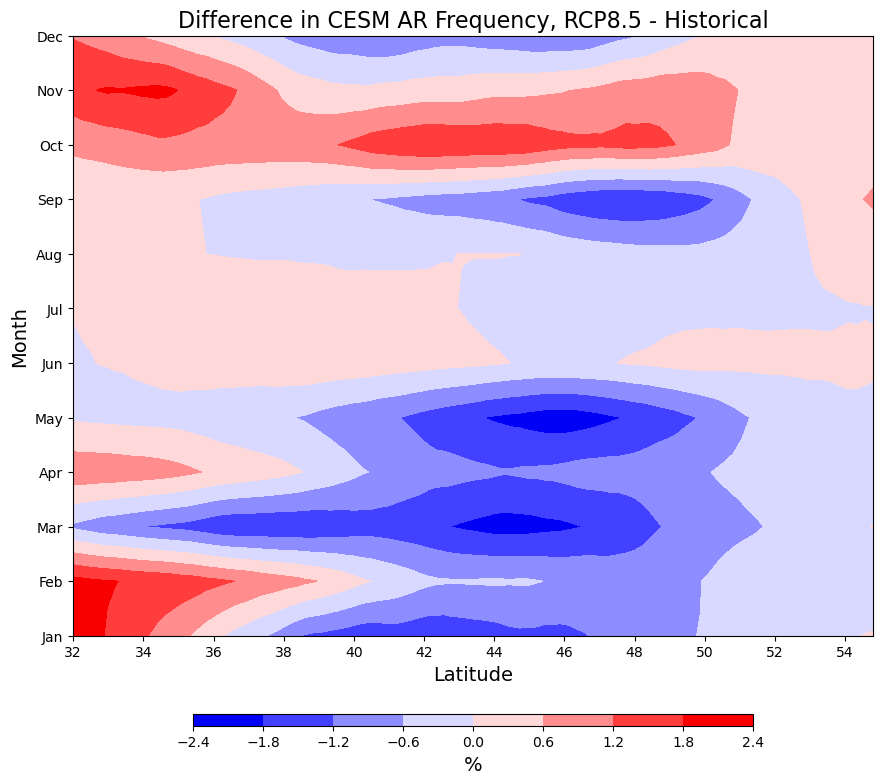

In [208]:
fig = plt.figure(figsize=(8,6))

cmap=plt.cm.get_cmap('seismic')

ax = fig.add_axes([0.,0.,1.,1.])

#lon=slice(230,255) # artmip
#lat_bounds = slice(32,55) # counts at coastlines

#lat = npercentARs_bymonth_zmean_rcp85.lat
lat = npercentARs_bymonth_zmean_rcp85.lat.sel(lat=slice(32,55)) #artmip lats
mon = npercentARs_bymonth_zmean_rcp85.month
#pc = ax.pcolormesh(mon, lat, npercentARs_bymonth_zmean_diff.transpose(), cmap=cmap, vmin=-6, vmax=6) #pcolor is very "blocky" due to monthly resolution
#pc = ax.contourf(mon, lat, npercentARs_bymonth_zmean_diff.transpose(), cmap=cmap, vmin=-6, vmax=6) #lat x month
pc = ax.contourf(lat, mon, npercentARs_bymonth_zmean_diff.sel(lat=slice(32,55)), cmap=cmap, vmin=-4, vmax=4) #month x lat

# July-June month ordering, y axis goes down in time -- still in progress to get this to work
#mon_alt = xr.concat([npercentARs_bymonth_zmean_rcp85.month.sel(month=slice(7,12)), npercentARs_bymonth_zmean_rcp85.month.sel(month=slice(1,6))], dim='month')
#pc = ax.contourf(lat, mon_alt.isel(month=slice(None, None, -1)), npercentARs_bymonth_zmean_diff.isel(month=slice(None, None, -1)), cmap=cmap, vmin=-4, vmax=4) #month x lat
#ax.set_xticks(np.arange(12)+1, ['J','F','M','A','M','J','J','A','S','O','N','D'])
#months_alt = ['Jul','Aug','Sep','Oct','Nov','Dec','Jan','Feb','Mar','Apr','May','Jun']

ax.set_yticks(np.arange(12)+1, months)
#ax.set_yticks(np.arange(12)+1, months_alt[::-1])

ax.set_ylabel('Month', fontsize=14)
ax.set_xlabel('Latitude', fontsize=14)

# add more latitude labels
lat_labels = np.arange(32, 55, 2)
ax.set_xticks(lat_labels)

# add colorbar
cbar_ax = fig.add_axes([0.15, -0.15, 0.7, 0.02])
cbar = plt.colorbar(pc, cax=cbar_ax, orientation='horizontal')
cbar.ax.set_xlabel('%', fontsize=14)

# add title
ax.set_title('Difference in CESM AR Frequency, RCP8.5 - Historical', fontsize=16); 

#plt.savefig('../figures/toSCP/npercentARs_restrWUS_CESM_diff_bymonth_zmean.png', bbox_inches='tight')
#plt.savefig('../figures/toSCP/npercentARs_CESM_diff_bymonth_zmean_config_artmip-lons.png', bbox_inches='tight')
#plt.savefig('../figures/toSCP/npercentARs_CESM_diff_bymonth_zmean_config_artmip-box.png', bbox_inches='tight')

In [46]:
npercentARs_bymonth_coastal_zmean_diff = npercentARs_bymonth_coastal_zmean_rcp85 - npercentARs_bymonth_coastal_zmean
print(npercentARs_bymonth_coastal_zmean_diff.min().values,
      npercentARs_bymonth_coastal_zmean_diff.max().values)

-5.016241039426522 5.140288978494624


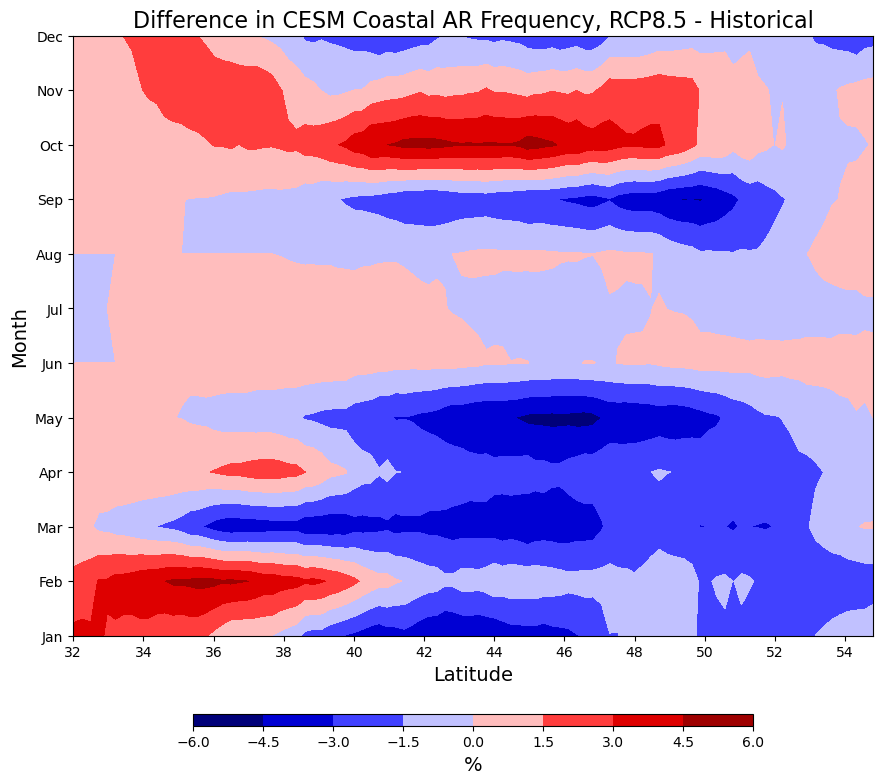

In [48]:
fig = plt.figure(figsize=(8,6))

cmap=plt.cm.get_cmap('seismic')

ax = fig.add_axes([0.,0.,1.,1.])

#lon=slice(230,255) # artmip
#lat_bounds = slice(32,55) # counts at coastlines

lat = npercentARs_bymonth_coastal_zmean_diff.lat.sel(lat=slice(32,55)) #artmip lats
mon = npercentARs_bymonth_coastal_zmean_diff.month
pc = ax.contourf(lat, mon, npercentARs_bymonth_coastal_zmean_diff.sel(lat=slice(32,55)), cmap=cmap, vmin=-6, vmax=6) #month x lat

ax.set_yticks(np.arange(12)+1, months)

ax.set_ylabel('Month', fontsize=14)
ax.set_xlabel('Latitude', fontsize=14)

# add more latitude labels
lat_labels = np.arange(32, 55, 2)
ax.set_xticks(lat_labels)

# add colorbar
cbar_ax = fig.add_axes([0.15, -0.15, 0.7, 0.02])
cbar = plt.colorbar(pc, cax=cbar_ax, orientation='horizontal')
cbar.ax.set_xlabel('%', fontsize=14)

# add title
ax.set_title('Difference in CESM Coastal AR Frequency, RCP8.5 - Historical', fontsize=16); 

#plt.savefig('../figures/toSCP/npercentARs_CESM_diff_bymonth_coastal_zmean_artmip-box.png', bbox_inches='tight')

In [50]:
client.close()
cluster.close()